In [50]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import interpn
import plotly.graph_objects as go
from functions import *

In [51]:
# u_data = read_pws_file("../data/111/PWS_NASA_Dataset111_u.faa")
# v_data = read_pws_file("../data/111/PWS_NASA_Dataset111_v.faa")
# w_data = read_pws_file("../data/111/PWS_NASA_Dataset111_w.faa")

u_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_u.faa")
v_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_v.faa")
w_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_w.faa")

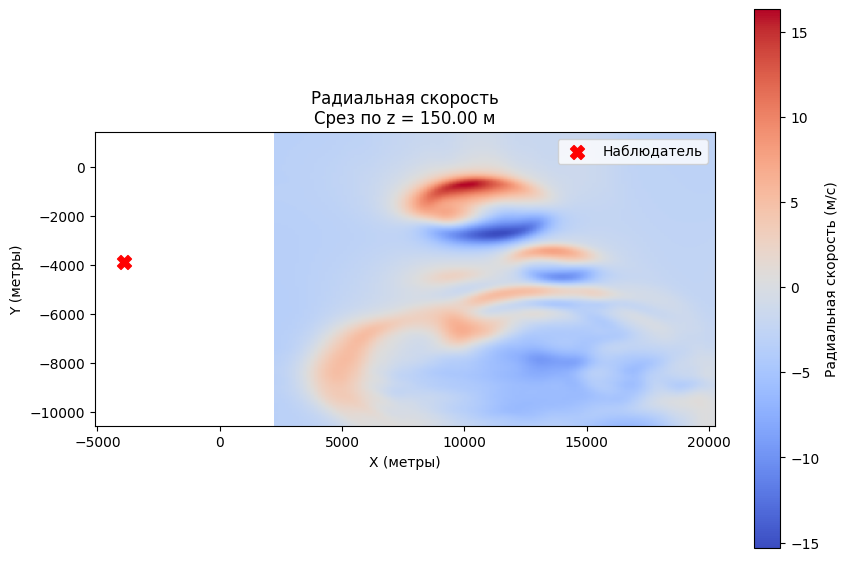

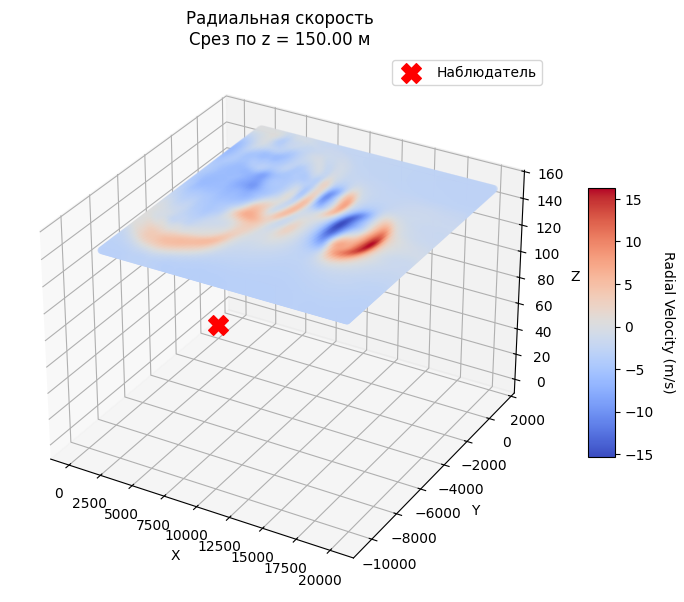

In [52]:
ix, iy, iz = u_data['dimensions']
xstart, ystart, zstart = u_data['origin_m']
dx, dy, dz = u_data['resolution_m']

#сетки координат
x = np.arange(xstart, xstart + ix * dx, dx)
y = np.arange(ystart, ystart + iy * dy, dy)
z = np.arange(zstart, zstart + iz * dz, dz)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Заданная точка
x0, y0, z0 = 0, 0, 0  

# Вычисление разностей координат
delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0

distance = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)

distance[distance == 0] = 1e-10

# Расчет радиальной скорости
U = u_data['data']
V = v_data['data']
W = w_data['data']
radial_velocity = (U * delta_x + V * delta_y + W * delta_z) / distance



z_slice = 3

# print("Размерность поля радиальных скоростей:", radial_velocity.shape)


plt.figure(figsize=(10, 7))
plt.imshow(
    radial_velocity[:, :, z_slice],
    cmap='coolwarm',
    origin='lower',
    extent=[x.min(), x.max(), y.min(), y.max()]
)
plt.colorbar(label='Радиальная скорость (м/с)')
plt.title(f'Радиальная скорость\nСрез по z = {z_slice * dz + zstart:.2f} м')

plt.scatter(-3900, -3900, color='red', marker='X', s=100, label='Наблюдатель') 
plt.legend()

plt.xlabel('X (метры)')
plt.ylabel('Y (метры)')
plt.show()

# --- 3D-график ---
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X[:, :, z_slice].flatten(),
    Y[:, :, z_slice].flatten(),
    Z[:, :, z_slice].flatten(),
    c=radial_velocity[:, :, z_slice].flatten(),
    cmap='coolwarm'
)

ax.scatter(x0, y0, z0, color='red', marker='X', s=200, label='Наблюдатель') 

cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=10)
cbar.set_label('Radial Velocity (m/s)', rotation=270, labelpad=15)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title(f'Радиальная скорость\nСрез по z = {z_slice * dz + zstart:.2f} м')
plt.legend()

plt.show()

In [53]:

def spherical_to_cartesian(azimuth_deg, elevation_deg):
    """Конвертируем углы в направляющий вектор"""
    azimuth = np.radians(azimuth_deg)
    elevation = np.radians(elevation_deg)
    x = np.cos(elevation) * np.cos(azimuth)
    y = np.cos(elevation) * np.sin(azimuth)
    z = np.sin(elevation)
    return np.array([x, y, z])

def line_parametric(t, origin, direction):
    """Параметрическое уравнение прямой"""
    return origin + direction * t

def find_intersection(matrix_shape, origin, direction):
    """Находим точки пересечения прямой с границами матрицы"""
    def get_t(axis, boundary):
        return (boundary - origin[axis]) / direction[axis] if direction[axis] != 0 else np.nan
    
    min_bounds = np.array([0, 0, 0])
    max_bounds = np.array(matrix_shape) - 1e-6  #  краевые эффекты
    
    t_enter = []
    t_exit = []
    
    for i in range(3):
        t1 = get_t(i, min_bounds[i])
        t2 = get_t(i, max_bounds[i])
        t_enter.append(min(t1, t2))
        t_exit.append(max(t1, t2))
    
    # Исправленный блок 
    valid_t_enter = [t for t in t_enter if not np.isnan(t)]
    valid_t_exit = [t for t in t_exit if not np.isnan(t)]
    
    t_start = max([0] + valid_t_enter) if valid_t_enter else np.nan 
    t_end = min(valid_t_exit) if valid_t_exit else np.nan    
    
    if np.isnan(t_start) or np.isnan(t_end) or t_start > t_end:
        return np.nan, np.nan
    
    
    # t_start = max(0, *[t for t in t_enter if not np.isnan(t)])
    # t_end = min(*[t for t in t_exit if not np.isnan(t)])
    
    return t_start, t_end

def trilinear_interpolation(matrix, x, y, z):
    """Трилинейная интерполяция"""
    x0, y0, z0 = np.floor([x, y, z]).astype(int)
    x1, y1, z1 = x0 + 1, y0 + 1, z0 + 1
    
    # обработка выхода за границы
    x0, x1 = np.clip([x0, x1], 0, matrix.shape[0]-1)
    y0, y1 = np.clip([y0, y1], 0, matrix.shape[1]-1)
    z0, z1 = np.clip([z0, z1], 0, matrix.shape[2]-1)
    
    xd = (x - x0) / (x1 - x0) if (x1 - x0) != 0 else 0
    yd = (y - y0) / (y1 - y0) if (y1 - y0) != 0 else 0
    zd = (z - z0) / (z1 - z0) if (z1 - z0) != 0 else 0

    c00 = matrix[x0, y0, z0] * (1 - xd) + matrix[x1, y0, z0] * xd
    c01 = matrix[x0, y0, z1] * (1 - xd) + matrix[x1, y0, z1] * xd
    c10 = matrix[x0, y1, z0] * (1 - xd) + matrix[x1, y1, z0] * xd
    c11 = matrix[x0, y1, z1] * (1 - xd) + matrix[x1, y1, z1] * xd

    c0 = c00 * (1 - yd) + c10 * yd
    c1 = c01 * (1 - yd) + c11 * yd

    return c0 * (1 - zd) + c1 * zd


In [54]:
def plot_line_results(V_radial, z0, x, y, z,  points, values, distance, observer_position):
    """
    Визуализация результатов: радиальная скорость и профиль скорости.
    
    Args:
        V_radial (np.ndarray): 3D массив радиальных скоростей.
        z0 (int): Величина в метрах среза  Z.
        x (np.ndarray): Координаты по оси X.
        y (np.ndarray): Координаты по оси Y.
        points (np.ndarray): Точки на линии.
        values (list): Значения радиальной скорости в точках.
        distance (np.ndarray): Расстояния между точками.
        observer_position (tuple): Позиция наблюдателя (x0, y0).
    """
    import matplotlib.pyplot as plt
    z_slice = np.argmin(np.abs(z - z0))  # Индекс слоя z

    # Срез радиальной скорости
    radial_slice = V_radial[:, :, z_slice]

    plt.figure(figsize=(14, 6))

    # Подграфик 1: Вид сверху
    plt.subplot(1, 2, 1)
    plt.imshow(
        radial_slice.T,
        extent=[x.min(), x.max(), y.min(), y.max()],
        origin='lower',
        cmap='coolwarm',
        alpha=0.6
    )
    plt.colorbar(label='Радиальная скорость (м/с)')

    # Точки линии
    plt.scatter(
        points[:, 0], points[:, 1],
        c=values, cmap='coolwarm', s=50, edgecolor='w',
        label='Точки линии'
    )
    plt.plot(points[:, 0], points[:, 1], color='blue', linestyle='-', linewidth=2, label='Линия')
    
    # Наблюдатель
    plt.scatter(
        observer_position[0]+0, observer_position[1]+0,
        color='red', marker='X', s=100, label='Наблюдатель'
    )

    # Подписи значений у точек
    for i in range(len(points)):
        plt.text(
            points[i, 0], points[i, 1],
            f'{values[i]:.1f} м/с',
            fontsize=8,
            ha='right',
            va='bottom',
            color='black',
            bbox=dict(boxstyle='round,pad=0.2',
                      edgecolor='white',
                      facecolor='white',
                      alpha=0.7)
        )

    plt.xlabel('X (м)')
    plt.ylabel('Y (м)')
    plt.title(f'Вид сверху (z={z0} м)')
    plt.legend()
    plt.grid(True)

    # Подграфик 2: Профиль скорости
    plt.subplot(1, 2, 2)
    plt.plot(distance, values, marker='o', linestyle='-', color='b')
    plt.xlabel('Расстояние вдоль линии (м)')
    plt.ylabel('Радиальная скорость (м/с)')
    plt.title('Профиль радиальной скорости')
    plt.grid(True)

    # Подписи значений у профиля
    for i in range(len(distance)):
        plt.text(
            distance[i], values[i],
            f'{values[i]:.1f} м/с',
            fontsize=8,
            ha='right',
            va='bottom',
            color='black',
            bbox=dict(boxstyle='round,pad=0.2',
                      edgecolor='white',
                      facecolor='white',
                      alpha=0.7)
        )

    plt.tight_layout()
    plt.show()

[[-4.00000000e+03  0.00000000e+00  1.46741782e+02]
 [-3.42857143e+03  0.00000000e+00  1.76689084e+02]
 [-2.85714286e+03  0.00000000e+00  2.06636387e+02]
 [-2.28571430e+03  0.00000000e+00  2.36583689e+02]
 [-1.71428573e+03  0.00000000e+00  2.66530991e+02]
 [-1.14285716e+03  0.00000000e+00  2.96478293e+02]
 [-5.71428593e+02  0.00000000e+00  3.26425596e+02]
 [-2.50000003e-05  0.00000000e+00  3.56372898e+02]
 [ 5.71428543e+02  0.00000000e+00  3.86320200e+02]
 [ 1.14285711e+03  0.00000000e+00  4.16267502e+02]
 [ 1.71428568e+03  0.00000000e+00  4.46214805e+02]
 [ 2.28571425e+03  0.00000000e+00  4.76162107e+02]
 [ 2.85714281e+03  0.00000000e+00  5.06109409e+02]
 [ 3.42857138e+03  0.00000000e+00  5.36056711e+02]
 [ 3.99999995e+03  0.00000000e+00  5.66004014e+02]]


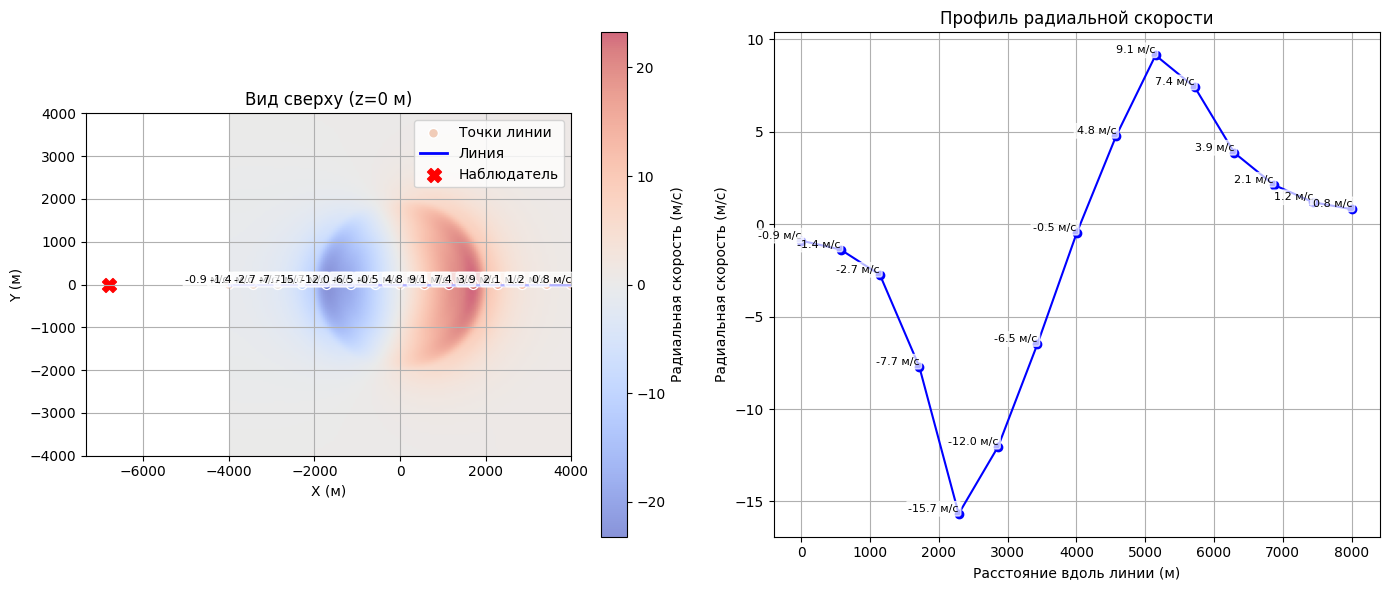

In [55]:
u_data = read_pws_file("../data/111/PWS_NASA_Dataset111_u.faa")
v_data = read_pws_file("../data/111/PWS_NASA_Dataset111_v.faa")
w_data = read_pws_file("../data/111/PWS_NASA_Dataset111_w.faa")

# u_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_u.faa")
# v_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_v.faa")
# w_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_w.faa")

origin = np.array(u_data['origin_m'])  # Начало координат датасета
dx, dy, dz = u_data['resolution_m']     # Шаг сетки
ix, iy, iz = u_data['dimensions']       # Размеры сетки

# Создание сетки в реальных координатах
x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Расчет радиальной скорости
x0, y0, z0 =  -6800, 0, 0# Точка наблюдателя
# Параметры линии
azimuth_deg = 0 # Горизонтальный угол
elevation_deg = 3  # Вертикальный угол
num_points = 15    # Количество точек



delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0
r = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)
with np.errstate(divide='ignore', invalid='ignore'):
    V_radial = (u_data['data'] * delta_x + 
                v_data['data'] * delta_y + 
                w_data['data'] * delta_z) / r
V_radial = np.nan_to_num(V_radial, nan=0.0)



direction = spherical_to_cartesian(azimuth_deg, elevation_deg)

# в реальных координатах
origin_line = np.array([x0, y0, z0])

# пересечения с матрицей
# min_bounds = np.array([x[0], y[0], z[0]])
# max_bounds = np.array([x[-1], y[-1], z[-1]])

matrix_shape = np.array([ix-1, iy-1, iz-1])

direction_normalized = direction / np.array([dx, dy, dz]) 

t_start, t_end = find_intersection(matrix_shape, 
                                  (origin_line - origin)/np.array([dx, dy, dz]), 
                                  direction_normalized)

t_values = np.linspace(t_start, t_end, num_points)
points = origin_line + direction * t_values[:, np.newaxis]  

values = []
for point in points:
    x_idx = (point[0] - origin[0]) / dx
    y_idx = (point[1] - origin[1]) / dy
    z_idx = (point[2] - origin[2]) / dz
    values.append(trilinear_interpolation(V_radial, x_idx, y_idx, z_idx))

print(points)
# print(values)
# print(ix)
# istance = [0.0]
distance = [0.0]  # Начальное расстояние 0 метров

for i in range(1, len(points)):
    dx = points[i][0] - points[i-1][0]
    dy = points[i][1] - points[i-1][1]
    dz = points[i][2] - points[i-1][2]
    segment = np.sqrt(dx**2 + dy**2 + dz**2)
    distance.append(distance[-1] + segment)  #

distance = np.array(distance)

plot_line_results(V_radial, z0, x, y, z, points, values, distance, observer_position=(x0, y0))


<h1><center>График — 1. Изначальная линия проходящая по диагонали через всю матрицу</center></h1>

[[-900.            0.           63.        ]
 [-836.73096782    0.           59.68421053]
 [-773.46193565    0.           56.36842105]
 [-710.19290347    0.           53.05263158]
 [-646.9238713     0.           49.73684211]
 [-583.65483912    0.           46.42105263]
 [-520.38580695    0.           43.10526316]
 [-457.11677477    0.           39.78947368]
 [-393.8477426     0.           36.47368421]
 [-330.57871042    0.           33.15789474]
 [-267.30967825    0.           29.84210526]
 [-204.04064607    0.           26.52631579]
 [-140.7716139     0.           23.21052632]
 [ -77.50258172    0.           19.89473684]
 [ -14.23354955    0.           16.57894737]
 [  49.03548263    0.           13.26315789]
 [ 112.3045148     0.            9.94736842]
 [ 175.57354698    0.            6.63157895]
 [ 238.84257915    0.            3.31578947]
 [ 302.11161133    0.            0.        ]]


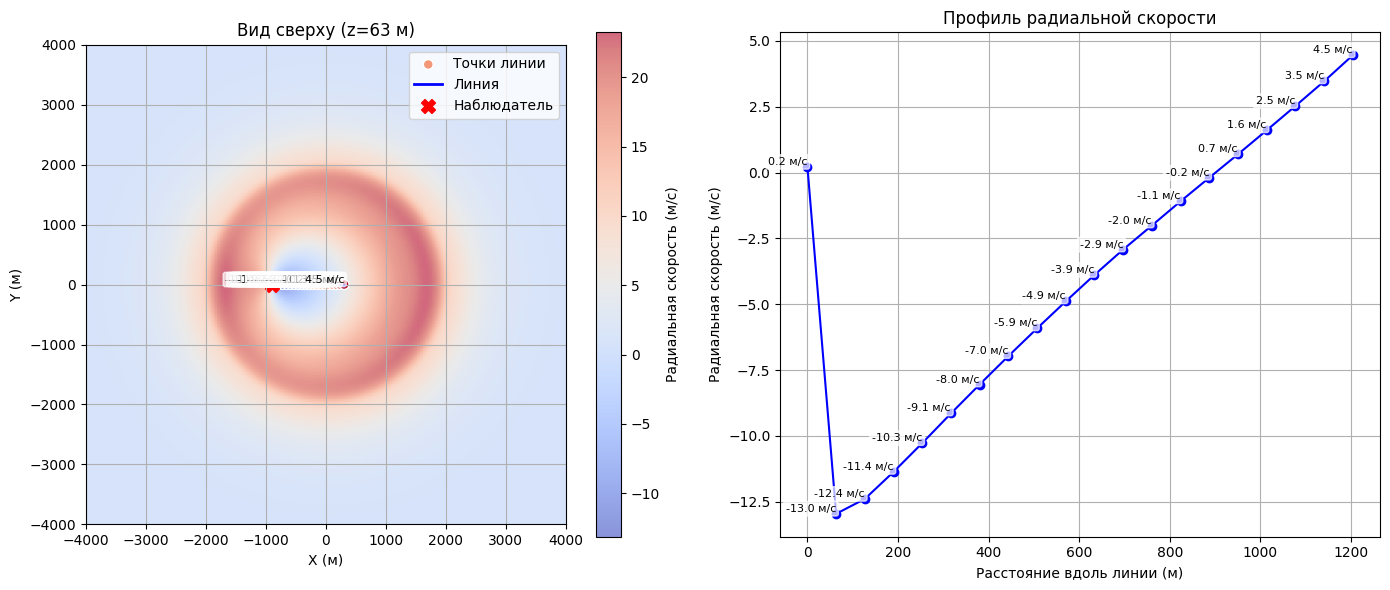

[[ -985.86511509     0.            67.5       ]
 [-1071.73023018     0.            72.        ]
 [-1157.59534527     0.            76.5       ]
 [-1243.46046036     0.            81.        ]
 [-1329.32557545     0.            85.5       ]
 [-1415.19069054     0.            90.        ]
 [-1501.05580563     0.            94.5       ]
 [-1586.92092072     0.            99.        ]
 [-1672.78603581     0.           103.5       ]
 [-1758.6511509      0.           108.        ]
 [-1844.51626599     0.           112.5       ]
 [-1930.38138108     0.           117.        ]
 [-2016.24649617     0.           121.5       ]
 [-2102.11161126     0.           126.        ]
 [-2187.97672635     0.           130.5       ]
 [-2273.84184144     0.           135.        ]
 [-2359.70695653     0.           139.5       ]
 [-2445.57207162     0.           144.        ]
 [-2531.43718671     0.           148.5       ]
 [-2617.3023018      0.           153.        ]
 [-2703.16741689     0.           157.5 

In [ ]:
u_data = read_pws_file("../data/111/PWS_NASA_Dataset111_u.faa")
v_data = read_pws_file("../data/111/PWS_NASA_Dataset111_v.faa")
w_data = read_pws_file("../data/111/PWS_NASA_Dataset111_w.faa")

# u_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_u.faa")
# v_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_v.faa")
# w_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_w.faa")

origin = np.array(u_data['origin_m'])  # Начало координат датасета
dx, dy, dz = u_data['resolution_m']     # Шаг сетки
ix, iy, iz = u_data['dimensions']       # Размеры сетки

# Создание сетки в реальных координатах
x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Расчет радиальной скорости
x0, y0, z0 =  -900, 0, 63 # Точка наблюдателя
#x0, y0, z0 =  -8541, 0, 463 # Точка наблюдателя
# Параметры линии
azimuth_deg = 0 # Горизонтальный угол
elevation_deg = -3  # Вертикальный угол
num_points = 20    # Количество точек



delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0
r = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)
with np.errstate(divide='ignore', invalid='ignore'):
    V_radial = (u_data['data'] * delta_x + 
                v_data['data'] * delta_y + 
                w_data['data'] * delta_z) / r
V_radial = np.nan_to_num(V_radial, nan=0.0)



direction = spherical_to_cartesian(azimuth_deg, elevation_deg)

# в реальных координатах
origin_line = np.array([x0, y0, z0])

# пересечения с матрицей
# min_bounds = np.array([x[0], y[0], z[0]])
# max_bounds = np.array([x[-1], y[-1], z[-1]])

matrix_shape = np.array([ix-1, iy-1, iz-1])

direction_normalized = direction / np.array([dx, dy, dz]) 

t_start, t_end = find_intersection(matrix_shape, 
                                  (origin_line - origin)/np.array([dx, dy, dz]), 
                                  direction_normalized)

t_values = np.linspace(t_start, t_end, num_points)
points = origin_line + direction * t_values[:, np.newaxis]  

values = []
for point in points:
    x_idx = (point[0] - origin[0]) / dx
    y_idx = (point[1] - origin[1]) / dy
    z_idx = (point[2] - origin[2]) / dz
    values.append(trilinear_interpolation(V_radial, x_idx, y_idx, z_idx))

print(points)
# print(values)
# print(ix)
# istance = [0.0]
distance = [0.0]  # Начальное расстояние 0 метров

for i in range(1, len(points)):
    dx = points[i][0] - points[i-1][0]
    dy = points[i][1] - points[i-1][1]
    dz = points[i][2] - points[i-1][2]
    segment = np.sqrt(dx**2 + dy**2 + dz**2)
    distance.append(distance[-1] + segment)  #

distance = np.array(distance)

plot_line_results(V_radial, z0, x, y, z, points, values, distance, observer_position=(x0, y0))


# Шаги изменения
dx = -85.86511509
dy = 4.5

first_x = points[0, 0]
first_y = points[0, 1]
first_z = points[0, 2]

new_data = []
for i in range(1, 90):
    new_x = first_x + i * dx
    new_y = first_y 
    new_z = first_z + i * dy
    new_data.append([new_x, new_y, new_z])

new_data = np.array(new_data)
print(new_data)


<h1><center>График — 2. Линия с измененным горизонтальным углом на +4</center></h1>

[[-1800.         -2800.            63.        ]
 [-1800.         -2714.13488491    58.5       ]
 [-1800.         -2628.26976981    54.        ]
 [-1800.         -2542.40465472    49.5       ]
 [-1800.         -2456.53953962    45.        ]
 [-1800.         -2370.67442453    40.5       ]
 [-1800.         -2284.80930943    36.        ]
 [-1800.         -2198.94419434    31.5       ]
 [-1800.         -2113.07907924    27.        ]
 [-1800.         -2027.21396415    22.5       ]
 [-1800.         -1941.34884905    18.        ]
 [-1800.         -1855.48373396    13.5       ]
 [-1800.         -1769.61861886     9.        ]
 [-1800.         -1683.75350377     4.5       ]
 [-1800.         -1597.88838867     0.        ]]


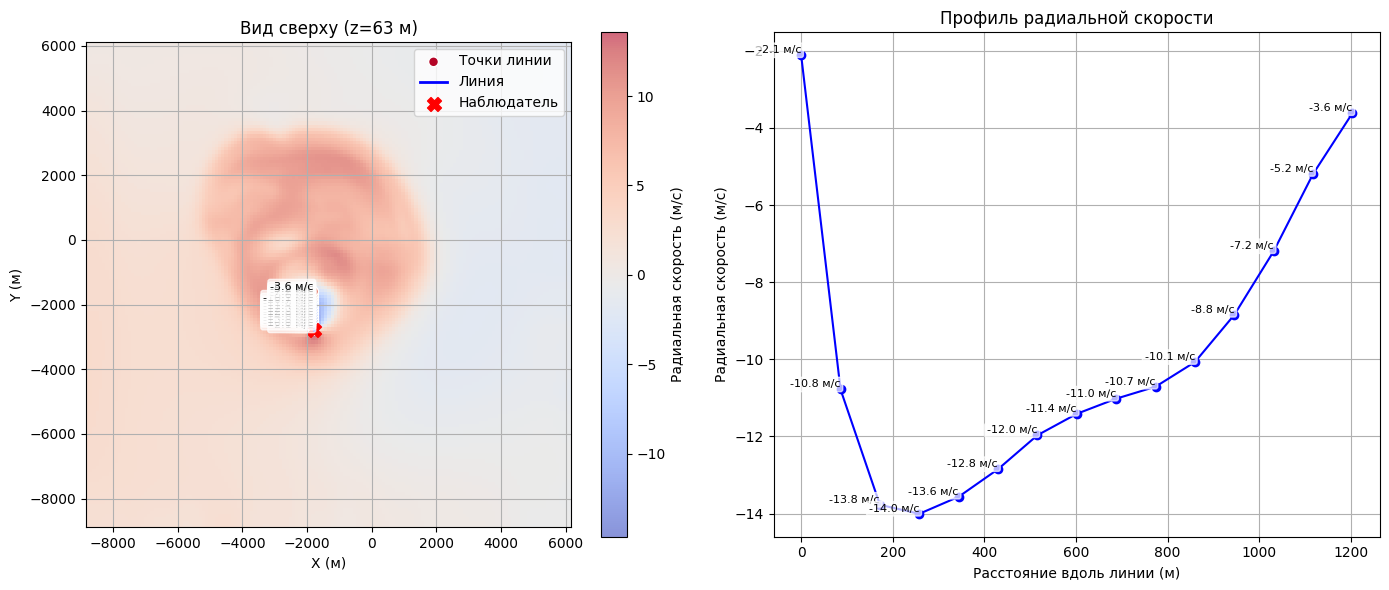

In [62]:
# u_data = read_pws_file("../data/111/PWS_NASA_Dataset111_u.faa")
# v_data = read_pws_file("../data/111/PWS_NASA_Dataset111_v.faa")
# w_data = read_pws_file("../data/111/PWS_NASA_Dataset111_w.faa")

# u_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_u.faa")
# v_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_v.faa")
# w_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_w.faa")

u_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset237_W9_2/PWS_NASA_Dataset237_u.faa")
v_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset237_W9_2/PWS_NASA_Dataset237_v.faa")
w_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset237_W9_2/PWS_NASA_Dataset237_w.faa")


origin = np.array(u_data['origin_m'])  # Начало координат датасета
dx, dy, dz = u_data['resolution_m']     # Шаг сетки
ix, iy, iz = u_data['dimensions']       # Размеры сетки

# Создание сетки в реальных координатах
x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Расчет радиальной скорости
x0, y0, z0 =  -1800, -2800, 63# Точка наблюдателя
# Параметры линии
azimuth_deg = 90 # Горизонтальный угол
elevation_deg = -3  # Вертикальный угол
num_points = 15    # Количество точек



delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0
r = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)
with np.errstate(divide='ignore', invalid='ignore'):
    V_radial = (u_data['data'] * delta_x + 
                v_data['data'] * delta_y + 
                w_data['data'] * delta_z) / r
V_radial = np.nan_to_num(V_radial, nan=0.0)



direction = spherical_to_cartesian(azimuth_deg, elevation_deg)

# в реальных координатах
origin_line = np.array([x0, y0, z0])

# пересечения с матрицей
# min_bounds = np.array([x[0], y[0], z[0]])
# max_bounds = np.array([x[-1], y[-1], z[-1]])

matrix_shape = np.array([ix-1, iy-1, iz-1])

direction_normalized = direction / np.array([dx, dy, dz]) 

t_start, t_end = find_intersection(matrix_shape, 
                                  (origin_line - origin)/np.array([dx, dy, dz]), 
                                  direction_normalized)

t_values = np.linspace(t_start, t_end, num_points)
points = origin_line + direction * t_values[:, np.newaxis]  

values = []
for point in points:
    x_idx = (point[0] - origin[0]) / dx
    y_idx = (point[1] - origin[1]) / dy
    z_idx = (point[2] - origin[2]) / dz
    values.append(trilinear_interpolation(V_radial, x_idx, y_idx, z_idx))

print(points)
# print(values)
# print(ix)
# istance = [0.0]
distance = [0.0]  # Начальное расстояние 0 метров

for i in range(1, len(points)):
    dx = points[i][0] - points[i-1][0]
    dy = points[i][1] - points[i-1][1]
    dz = points[i][2] - points[i-1][2]
    segment = np.sqrt(dx**2 + dy**2 + dz**2)
    distance.append(distance[-1] + segment)  #

distance = np.array(distance)

plot_line_results(V_radial, z0, x, y, z, points, values, distance, observer_position=(x0, y0))


<h1><center>График — 3. Линия с измененным горизонтальным углом на -4</center></h1>

[[2700.         1100.           63.        ]
 [2785.86511509 1100.           58.5       ]
 [2871.73023019 1100.           54.        ]
 [2957.59534528 1100.           49.5       ]
 [3043.46046038 1100.           45.        ]
 [3129.32557547 1100.           40.5       ]
 [3215.19069057 1100.           36.        ]
 [3301.05580566 1100.           31.5       ]
 [3386.92092076 1100.           27.        ]
 [3472.78603585 1100.           22.5       ]
 [3558.65115095 1100.           18.        ]
 [3644.51626604 1100.           13.5       ]
 [3730.38138114 1100.            9.        ]
 [3816.24649623 1100.            4.5       ]
 [3902.11161133 1100.            0.        ]]


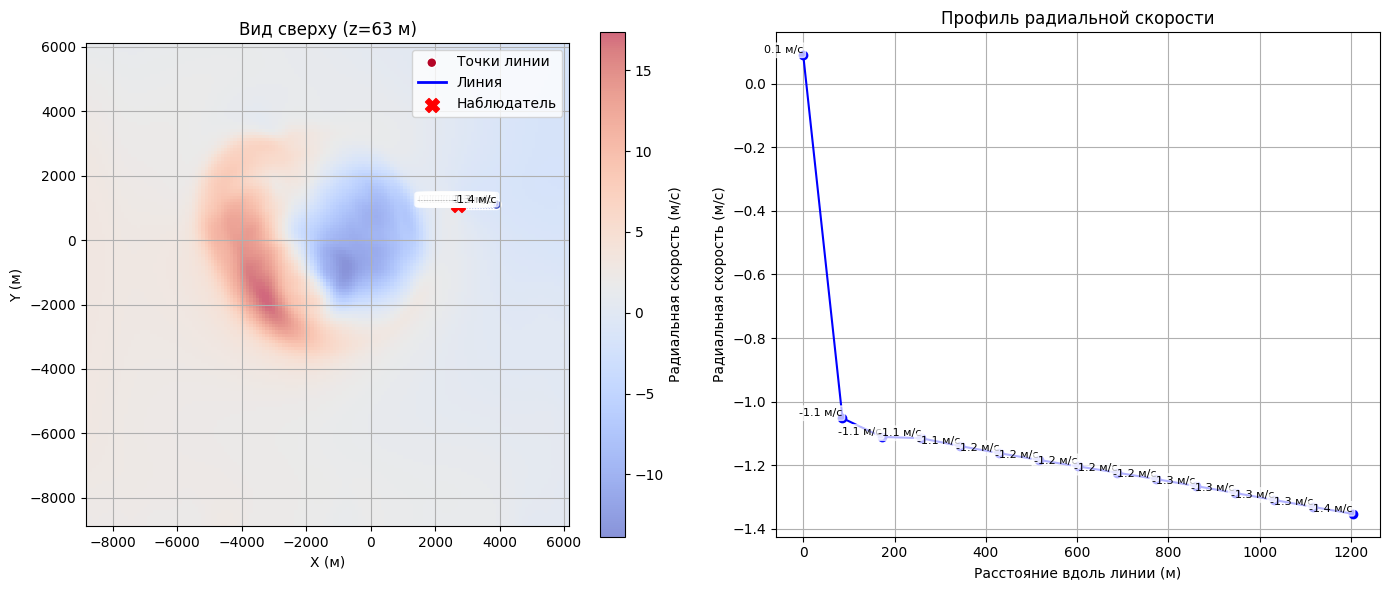

In [58]:
# u_data = read_pws_file("../data/111/PWS_NASA_Dataset111_u.faa")
# v_data = read_pws_file("../data/111/PWS_NASA_Dataset111_v.faa")
# w_data = read_pws_file("../data/111/PWS_NASA_Dataset111_w.faa")

# u_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_u.faa")
# v_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_v.faa")
# w_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_w.faa")

u_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset237_W9_2/PWS_NASA_Dataset237_u.faa")
v_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset237_W9_2/PWS_NASA_Dataset237_v.faa")
w_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset237_W9_2/PWS_NASA_Dataset237_w.faa")


origin = np.array(u_data['origin_m'])  # Начало координат датасета
dx, dy, dz = u_data['resolution_m']     # Шаг сетки
ix, iy, iz = u_data['dimensions']       # Размеры сетки

# Создание сетки в реальных координатах
x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Расчет радиальной скорости
x0, y0, z0 =  2700, 1100, 63# Точка наблюдателя
# Параметры линии
azimuth_deg = 0 # Горизонтальный угол
elevation_deg = -3  # Вертикальный угол
num_points = 15    # Количество точек



delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0
r = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)
with np.errstate(divide='ignore', invalid='ignore'):
    V_radial = (u_data['data'] * delta_x + 
                v_data['data'] * delta_y + 
                w_data['data'] * delta_z) / r
V_radial = np.nan_to_num(V_radial, nan=0.0)



direction = spherical_to_cartesian(azimuth_deg, elevation_deg)

# в реальных координатах
origin_line = np.array([x0, y0, z0])

# пересечения с матрицей
# min_bounds = np.array([x[0], y[0], z[0]])
# max_bounds = np.array([x[-1], y[-1], z[-1]])

matrix_shape = np.array([ix-1, iy-1, iz-1])

direction_normalized = direction / np.array([dx, dy, dz]) 

t_start, t_end = find_intersection(matrix_shape, 
                                  (origin_line - origin)/np.array([dx, dy, dz]), 
                                  direction_normalized)

t_values = np.linspace(t_start, t_end, num_points)
points = origin_line + direction * t_values[:, np.newaxis]  

values = []
for point in points:
    x_idx = (point[0] - origin[0]) / dx
    y_idx = (point[1] - origin[1]) / dy
    z_idx = (point[2] - origin[2]) / dz
    values.append(trilinear_interpolation(V_radial, x_idx, y_idx, z_idx))

print(points)
# print(values)
# print(ix)
# istance = [0.0]
distance = [0.0]  # Начальное расстояние 0 метров

for i in range(1, len(points)):
    dx = points[i][0] - points[i-1][0]
    dy = points[i][1] - points[i-1][1]
    dz = points[i][2] - points[i-1][2]
    segment = np.sqrt(dx**2 + dy**2 + dz**2)
    distance.append(distance[-1] + segment)  #

distance = np.array(distance)

plot_line_results(V_radial, z0, x, y, z, points, values, distance, observer_position=(x0, y0))


<h1><center>График — 5. Линия с измененным вертикальным углом на +4</center></h1>

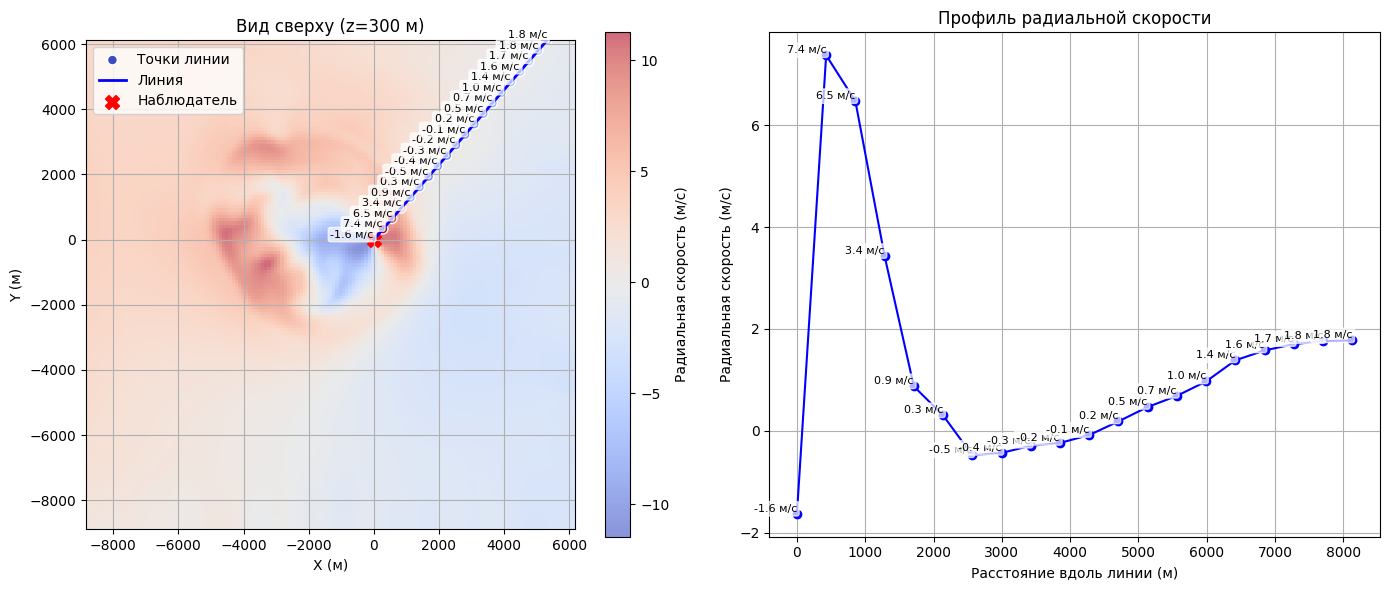

In [59]:
origin = np.array(u_data['origin_m'])  # Начало координат датасета
dx, dy, dz = u_data['resolution_m']     # Шаг сетки
ix, iy, iz = u_data['dimensions'] 
x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Расчет радиальной скорости
x0, y0, z0 =  0, 0, 300 # Точка наблюдателя
# Параметры линии
azimuth_deg = 49    # Горизонтальный угол
elevation_deg = 4  # Вертикальный угол
num_points = 20    # Количество точек
delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0
r = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)
with np.errstate(divide='ignore', invalid='ignore'):
    V_radial = (u_data['data'] * delta_x + 
                v_data['data'] * delta_y + 
                w_data['data'] * delta_z) / r
V_radial = np.nan_to_num(V_radial, nan=0.0)



direction = spherical_to_cartesian(azimuth_deg, elevation_deg)
origin_line = np.array([x0, y0, z0])
# min_bounds = np.array([x[0], y[0], z[0]])
# max_bounds = np.array([x[-1], y[-1], z[-1]])
matrix_shape = np.array([ix-1, iy-1, iz-1])

direction_normalized = direction / np.array([dx, dy, dz]) 

t_start, t_end = find_intersection(matrix_shape, 
                                  (origin_line - origin)/np.array([dx, dy, dz]), 
                                  direction_normalized)

t_values = np.linspace(t_start, t_end, num_points)
points = origin_line + direction * t_values[:, np.newaxis]  
values = []
for point in points:
    x_idx = (point[0] - origin[0]) / dx
    y_idx = (point[1] - origin[1]) / dy
    z_idx = (point[2] - origin[2]) / dz
    values.append(trilinear_interpolation(V_radial, x_idx, y_idx, z_idx))
# print(points)
# print(values)
# print(ix)
# istance = [0.0]
distance = [0.0]  

for i in range(1, len(points)):
    dx = points[i][0] - points[i-1][0]
    dy = points[i][1] - points[i-1][1]
    dz = points[i][2] - points[i-1][2]
    segment = np.sqrt(dx**2 + dy**2 + dz**2)
    distance.append(distance[-1] + segment)  #
distance = np.array(distance)
plot_line_results(V_radial, z0, x, y, z, points, values, distance, observer_position=(x0, y0))

<h1><center>График — 5. Линия с измененным вертикальным углом на +4 и горизонтальный угол на +4</center></h1>

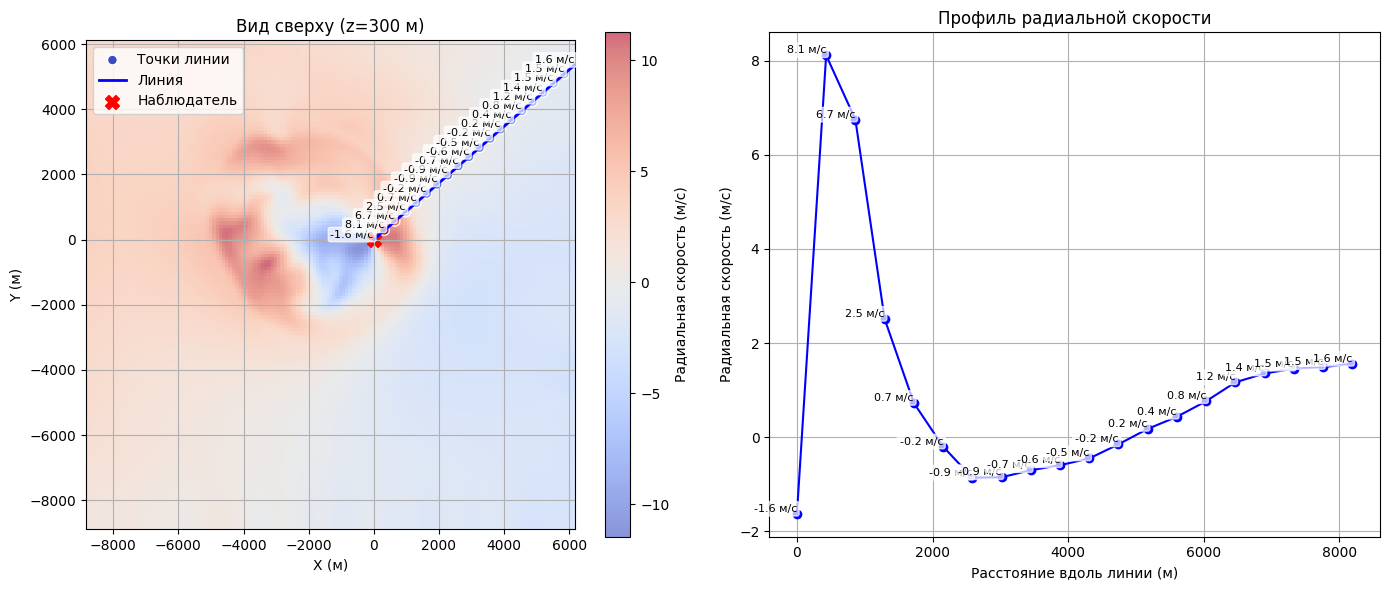

In [60]:
origin = np.array(u_data['origin_m'])  # Начало координат датасета
dx, dy, dz = u_data['resolution_m']     # Шаг сетки
ix, iy, iz = u_data['dimensions'] 
x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Расчет радиальной скорости
x0, y0, z0 =  0, 0, 300 # Точка наблюдателя
# Параметры линии
azimuth_deg = 41    # Горизонтальный угол
elevation_deg = 4  # Вертикальный угол
num_points = 20    # Количество точек
delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0
r = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)
with np.errstate(divide='ignore', invalid='ignore'):
    V_radial = (u_data['data'] * delta_x + 
                v_data['data'] * delta_y + 
                w_data['data'] * delta_z) / r
V_radial = np.nan_to_num(V_radial, nan=0.0)



direction = spherical_to_cartesian(azimuth_deg, elevation_deg)
origin_line = np.array([x0, y0, z0])
# min_bounds = np.array([x[0], y[0], z[0]])
# max_bounds = np.array([x[-1], y[-1], z[-1]])
matrix_shape = np.array([ix-1, iy-1, iz-1])

direction_normalized = direction / np.array([dx, dy, dz]) 

t_start, t_end = find_intersection(matrix_shape, 
                                  (origin_line - origin)/np.array([dx, dy, dz]), 
                                  direction_normalized)

t_values = np.linspace(t_start, t_end, num_points)
points = origin_line + direction * t_values[:, np.newaxis]  
values = []
for point in points:
    x_idx = (point[0] - origin[0]) / dx
    y_idx = (point[1] - origin[1]) / dy
    z_idx = (point[2] - origin[2]) / dz
    values.append(trilinear_interpolation(V_radial, x_idx, y_idx, z_idx))
# print(points)
# print(values)
# print(ix)
# istance = [0.0]
distance = [0.0]  

for i in range(1, len(points)):
    dx = points[i][0] - points[i-1][0]
    dy = points[i][1] - points[i-1][1]
    dz = points[i][2] - points[i-1][2]
    segment = np.sqrt(dx**2 + dy**2 + dz**2)
    distance.append(distance[-1] + segment)  #
distance = np.array(distance)
plot_line_results(V_radial, z0, x, y, z, points, values, distance, observer_position=(x0, y0))

<h1><center>График — 6. Линия с измененным вертикальным углом на +4 и горизонтальный угол на -4</center></h1>